# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "BUI PHONG HOP"  # TODO: Họ và tên
STUDENT_ID = "2510082"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: BUI PHONG HOP (2510082)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\Admin\Desktop\MLIOT-2026\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
# Khởi tạo một batch logits
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
# Zi - Zmax
shifted_logits = logits - logits.max(axis = 1 , keepdims = True)
# e^(Zi - Zmax)
exp_logits = np.exp(shifted_logits)
# Pi = e^(Zi - Zmax) / sum(e^(Zi - Zmax), i thuộc [1 , num_classes])
class_probabilities = exp_logits / exp_logits.sum(axis = 1, keepdims = True)
# class có xác suất lớn nhất của từng mẫu.
predicted_classes = np.argmax(class_probabilities, axis = 1)
# xác suất lớn nhất của từng mẫu.
confidence_scores = np.max(class_probabilities, axis = 1)

print("shifted_logits:\n", shifted_logits)
print("\nclass_probabilities:\n", class_probabilities)
print("\npredicted_classes:", predicted_classes)
print("\nconfidence_scores:", confidence_scores)

shifted_logits:
 [[ 0.  -1.  -1.9]
 [-1.   0.  -2. ]
 [-5.  -4.   0. ]
 [ 0.   0.   0. ]]

class_probabilities:
 [[0.65900114 0.24243297 0.09856589]
 [0.24472847 0.66524096 0.09003057]
 [0.00657326 0.01786798 0.97555875]
 [0.33333333 0.33333333 0.33333333]]

predicted_classes: [0 1 2 0]

confidence_scores: [0.65900114 0.66524096 0.97555875 0.33333333]


In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
train_feature_mean = X_train.mean(axis = 0)
train_feature_std = X_train.std(axis = 0)
# Chuẩn hoá X_train và X_val theo phương pháp StandardScaler
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

print("train_feature_mean:", train_feature_mean)
print("train_feature_std:", train_feature_std)
print("\nX_train_scaled:\n", X_train_scaled)
print("\nX_val_scaled:\n", X_val_scaled)

train_feature_mean: [172.5         69.16666667   1.65        28.16666667]
train_feature_std: [ 7.47774476 13.04372987  0.79109629  7.64671316]

X_train_scaled:
 [[-0.3343254  -0.31943828 -0.56883088 -0.80644671]
 [ 1.0029762   0.83053953  0.94805147  0.89363014]
 [-1.671627   -1.4694161  -1.07445834 -1.19877214]
 [ 0.3343254   0.06388766 -0.18961029 -0.02179586]
 [-0.60178572 -0.70276422 -0.82164461 -0.54489643]
 [ 1.27043652  1.59719141  1.70649265  1.67828099]]

X_val_scaled:
 [[-0.06686508 -0.08944272 -0.31601716 -0.28334614]
 [ 2.34027779  1.98051735  2.21212011  2.20138156]]


In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
# trả về danh sách chứa kết quả so sánh nhãn dự đoán với nhãn thật của từng mẫu
correct_mask = predicted_classes == true_labels
# trả về danh sách chứa kết quả so sánh chỉ số tự tin với confidence_threshold
high_confidence_mask = confidence_scores >= confidence_threshold
# Những mẫu không tốt: đoán sai HOẶC độ tự tin thấp
review_mask = (~correct_mask) | (~high_confidence_mask)
# Lấy địa chỉ của mẫu không tốt
review_indices = np.where(review_mask)[0]

print("correct_mask:", correct_mask)
print("high_confidence_mask:", high_confidence_mask)
print("review_mask:", review_mask)
print("review_indices:", review_indices)

correct_mask: [ True False  True False]
high_confidence_mask: [False False  True False]
review_mask: [ True  True False  True]
review_indices: [0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
# Chuẩn hoá các giá trị đại diện cho các pixel về đoạn [0 , 1]
normalized_batch = image_batch_uint8.astype(np.float32) / 255
# flip ngang
augmented_batch = normalized_batch[: , : , ::-1 , :].copy()
augmented_batch[0, 0, 0, 0] = 1.0

print(f"normalized_batch dtype/range: {normalized_batch.dtype} / [{normalized_batch.min():.2f} , {normalized_batch.max():.2f}]")
print("normalized_batch và augmented_batch khác vùng nhớ:",
      not np.shares_memory(normalized_batch, augmented_batch))
print("normalized_batch[0,0,0,0]:", normalized_batch[0, 0, 0, 0])
print("augmented_batch[0,0,0,0]:", augmented_batch[0, 0, 0, 0])

normalized_batch dtype/range: float32 / [0.00 , 0.37]
normalized_batch và augmented_batch khác vùng nhớ: True
normalized_batch[0,0,0,0]: 0.0
augmented_batch[0,0,0,0]: 1.0


# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

> Trả lời câu hỏi mở đầu

1. Mỗi dòng trong bảng dữ liệu đại diện cho **một mẫu xe**, mô tả bởi các thông số kỹ thuật (kích thước, động cơ, mức tiêu hao nhiên liệu, mức độ rủi ro bảo hiểm, giá bán,...)
2. Ký hiệu **missing value** trong file automobile_raw.csv gốc là dấu hỏi chấm "?".
3. **symboling** là **Mức đánh giá rủi ro bảo hiểm** do các công ty bảo hiểm gán cho xe, nhận giá trị nguyên từ -3 đến +3: giá trị càng cao ứng với sự gia tăng của mức độ rủi ro.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# D1: Load và inspect raw CSV
# load dữ liệu từ dataset và lưu phần dữ liệu dưới dạng string
raw_df = pd.read_csv(DATA_PATH, dtype = str)
raw_shape = raw_df.shape          # (205 , 26)
# Tính tổng các giá trị missing value
# sum() thứ nhất: trả về mảng chứa tổng missing value theo từng cột
# sum() thứ hai: trả về tổng các giá trị missing value theo từng cột trong mảng vừa tạo
raw_missing_marker_count = int((raw_df == "?").sum().sum())

print("raw_shape:", raw_shape)
print("raw_missing_marker_count:", raw_missing_marker_count)
raw_df.head()

raw_shape: (205, 26)
raw_missing_marker_count: 59


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.60,...,130,mpfi,3.47,2.68,9.00,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.50,...,152,mpfi,2.68,3.47,9.00,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.80,...,109,mpfi,3.19,3.40,10.00,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.40,...,136,mpfi,3.19,3.40,8.00,115,5500,18,22,17450


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
# chuyển các chỗ có dấu ? bằng nan
df_clean = raw_df.replace("?" , np.nan)
# chuyển các cột từ string sang dạng số, các giá trị không chuyển được thì đổi thành nan
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(raw_df[column] , errors = "coerce")

# tổng số missing value theo từng cột (từng feature)
missing_by_column = df_clean.isna().sum()
print(missing_by_column[missing_by_column > 0])
df_clean.dtypes

normalized_losses    41
num_doors             2
bore                  4
stroke                4
horsepower            2
peak_rpm              2
price                 4
dtype: int64


symboling              int64
normalized_losses    float64
make                  object
fuel_type             object
aspiration            object
num_doors             object
body_style            object
drive_wheels          object
engine_location       object
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type           object
num_cylinders         object
engine_size            int64
fuel_system           object
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                float64
dtype: object

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với **price**, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- **normalized_losses** thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

> Trả lời câu hỏi:
1. Không nên fill tất cả các cột numeric bằng cùng một giá trị vì mỗi cột có thang giá trị và ý nghĩa vật lý khác nhau (ví dụ: **horsepower** và **price** chênh lệch nhau rất lớn), nên fill một giá trị cho cột này có thể vô lý hoàn toàn với cột khác, và ảnh hưởng đến phân phối cũng như tương quan giữa các biến số. 
2. Với **price**, chỉ có 4/205 dòng thiếu (khoảng 2% < 5%): **drop** các dòng thiếu sẽ hợp lý hơn fill, con số nhỏ không ảnh hưởng nhiều đến kích thước mẫu, trong khi fill (ví dụ bằng mean/median) sẽ tạo ra giá trị ảo và có thể làm sai lệch chính các phân tích dựa trên biến số này. 
3. Cột **normalized_losses** thiếu tới 41/205 dòng (~20%): nên nếu drop toàn bộ các dòng này sẽ mất một lượng dữ liệu đáng kể, còn nếu fill thì độ tin cậy của giá trị fill cũng thấp hơn do thiếu quá nhiều — vì vậy trong bài này **normalized_losses** không được đưa vào **AUTO_FEATURES** để tránh gây ảnh hưởng đến quá trình phân tích dữ liệu

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# D3: DataFrame sang NumPy
# Bỏ đi những hàng có chứa missing value
analysis_df = df_clean.dropna(subset = AUTO_FEATURES , how = "any").reset_index(drop = True)
# Chuyển sang numpy (ma trận dữ liệu)
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype = np.float64)

# Chuẩn hoá ma trận dữ liệu mới tạo bằng StandardScale
auto_feature_mean = X_auto.mean(axis = 0)
auto_feature_std = X_auto.std(axis = 0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

print("analysis_df shape:", analysis_df.shape)
print("X_auto shape:", X_auto.shape)
print("auto_feature_mean:", auto_feature_mean.round(2))
print("auto_feature_std:", auto_feature_std.round(2))

analysis_df shape: (199, 26)
X_auto shape: (199, 6)
auto_feature_mean: [ 2556.03   126.82   103.4     25.2     30.68 13243.43]
auto_feature_std: [5.18550e+02 4.16500e+01 3.74600e+01 6.44000e+00 6.83000e+00 7.95864e+03]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# D4: Outlier theo price z-score
# Chuyển cột biến số price sang numpy
price_values = analysis_df["price"].to_numpy(dtype = np.float64)

# Z-score: z-score = (x - mean) / std
price_mean = price_values.mean()
price_std = price_values.std()
price_z = (price_values - price_mean) / price_std

# Lập danh sách chứa các outlier
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df.loc[price_outlier_mask]

print("So luong outlier:", price_outlier_mask.sum())
price_outliers[["make", "body_style", "price"]]

So luong outlier: 14


,make,body_style,price
14,bmw,sedan,30760.0
15,bmw,sedan,41315.0
16,bmw,sedan,36880.0
44,jaguar,sedan,32250.0
45,jaguar,sedan,35550.0
46,jaguar,sedan,36000.0
67,mercedes-benz,sedan,31600.0
68,mercedes-benz,sedan,34184.0
69,mercedes-benz,convertible,35056.0
70,mercedes-benz,sedan,40960.0


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# D5: Correlation va GroupBy
# Tính hệ số tương quan pearson và groupy các biến số price theo các loài của body_style
engine_price_corr = np.corrcoef(analysis_df["engine_size"], analysis_df["price"])[0, 1]
price_by_body_style = df_clean.groupby("body_style")["price"].mean().sort_index()

np.set_printoptions(precision = 2, suppress = True)
print(f"engine_price_corr: {engine_price_corr:.2f}")
print(price_by_body_style.round(2))

engine_price_corr: 0.87
body_style
convertible    21890.50
hardtop        22208.50
hatchback       9957.44
sedan          14459.76
wagon          12371.96
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

> Chọn đồ thị Histogram để biểu diễn phân phối của một biến số

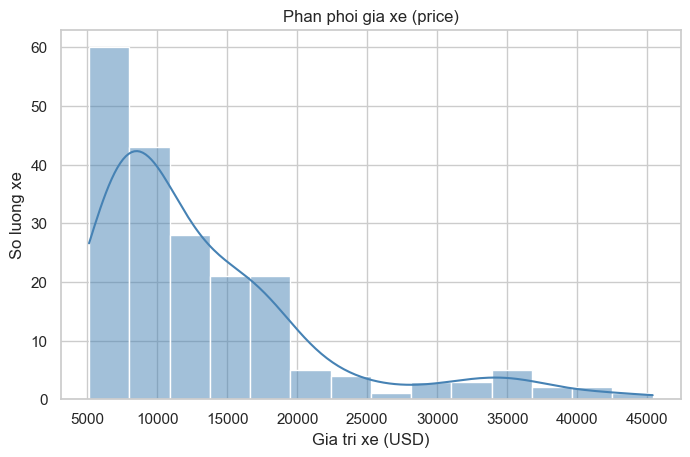

Giá trị skewness:  1.79
Giá trị meadian:  10345.0


In [20]:
# M2.1: Phan phoi cua price
fig, ax = plt.subplots()
sns.histplot(analysis_df["price"], kde = True, ax = ax, color = "steelblue")
ax.set_title("Phan phoi gia xe (price)")
ax.set_xlabel("Gia tri xe (USD)")
ax.set_ylabel("So luong xe")
plt.show()

print("Giá trị skewness: ", analysis_df["price"].skew().round(2))
print("Giá trị meadian: " , analysis_df["price"].median().round(2))

NHẬN XÉT:
1. Phân phối **price** lệch phải khá rõ (skewness ≈ 1.79 > 0): đỉnh đường KDE nằm bên trái và có đuôi kéo dài về phía bên phải.
2. Phần lớn các xe thuộc loại giá rẻ (median ≈ 10,345 USD) nhưng có một số ít xe hạng sang giá trên 30,000 – 45,000 USD kéo lệnh dữ liệu sang bên phải (mean > meadian).

## M2.2 Dataset có cân bằng theo body style không?

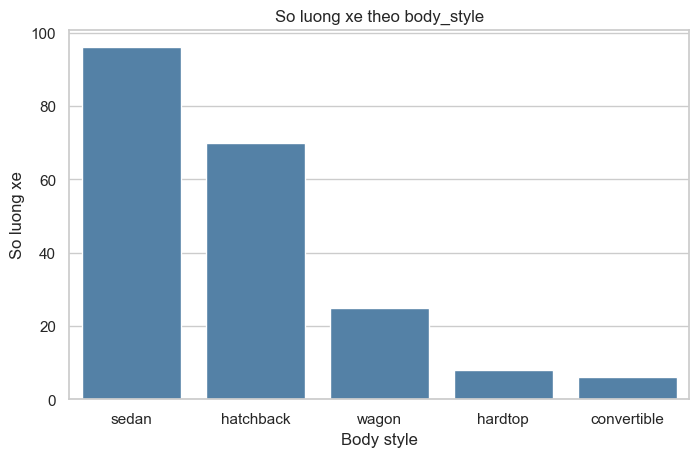

In [21]:
# M2.2: Countplot theo body_style
fig, ax = plt.subplots()
order = df_clean["body_style"].value_counts().index
sns.countplot(data = df_clean, x = "body_style", order = order, ax = ax, color = "steelblue")

ax.set_title("So luong xe theo body_style")
ax.set_xlabel("Body style")
ax.set_ylabel("So luong xe")
plt.show()

NHẬN XÉT:
 1. **body_style** — **sedan** (96 xe) và **hatchback** (70 xe) chiếm phần lớn.
 2. **convertible** (6 xe) và **hardtop** (8 xe). Chứng tỏ rằng: Dataset không cân bằng và rất ít, nên các kết luận thống kê cho hai nhóm này cần được diễn giải thận trọng vì cỡ mẫu nhỏ

## M2.3 Price khác nhau theo body style ra sao?

> Chọn boxplot để so sánh theo loại của body_style

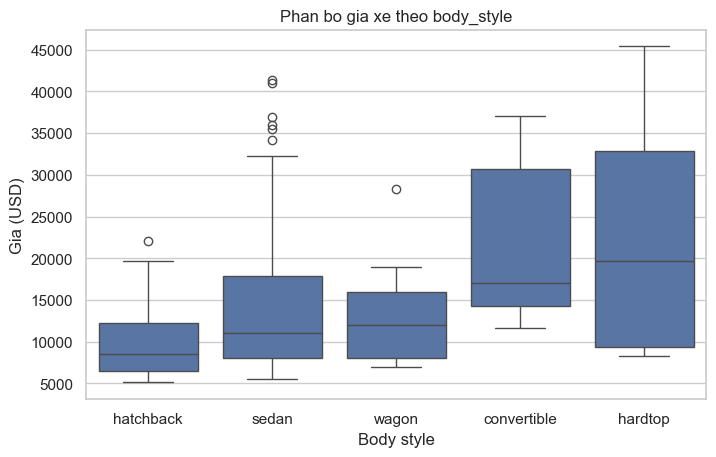

body_style
hatchback       8499.0
sedan          11078.5
wagon          11992.0
convertible    17084.5
hardtop        19687.5
Name: price, dtype: float64


In [22]:
# M2.3: Boxplot price theo body_style
fig, ax = plt.subplots()
# Tạo thứ tự tăng dần theo median
increase_order = analysis_df.groupby("body_style")["price"].median().sort_values().index
sns.boxplot(data=analysis_df, x="body_style", y = "price", order = increase_order, ax = ax)

ax.set_title("Phan bo gia xe theo body_style")
ax.set_xlabel("Body style")
ax.set_ylabel("Gia (USD)")
plt.show()

median_show = analysis_df.groupby("body_style")["price"].median().sort_values()
print(median_show)

NHẬN XÉT:
1. **convertible** và **hardtop** có mức giá trung bình cao nhất (khoảng 17084.5 – 19687.5 USD), trong khi **hatchback** rẻ nhất (trung bình ≈ 8499.0 USD); 
2. **sedan** tuy phổ biến nhất nhưng giá trung bình chỉ ở mức trung bình thấp (≈14,460 USD), cho thấy body style phổ biến không đồng nghĩa với giá cao, và độ phân tán giá trong nhóm **sedan** khá lớn.

## M2.4 Engine size liên quan thế nào tới price?

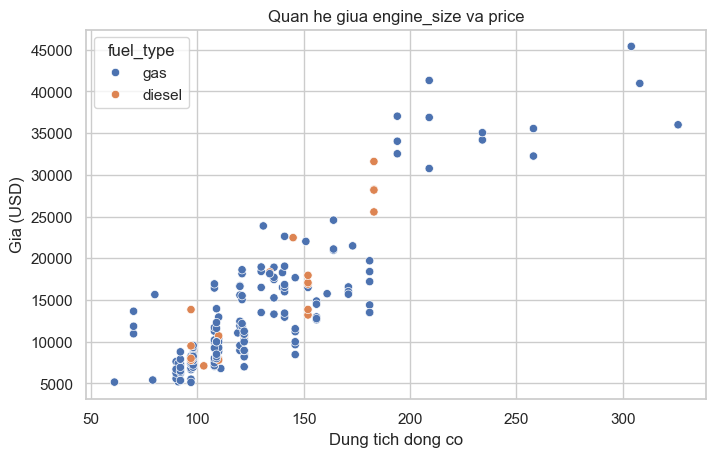

In [23]:
# M2.4: Scatterplot engine_size vs price, hue=fuel_type
fig, ax = plt.subplots()
sns.scatterplot(data=analysis_df, x = "engine_size", y = "price", hue = "fuel_type", ax = ax)
ax.set_title("Quan he giua engine_size va price")
ax.set_xlabel("Dung tich dong co")
ax.set_ylabel("Gia (USD)")
plt.show()

NHẬN XÉT:
1. **engine_size** và **price** có tương quan dương mạnh  — xe có dung tích động cơ lớn hơn thường có giá cao hơn rõ rệt
2. Xe chạy diesel (20/205 xe) có xu hướng nằm rải rác ở vùng dung tích động cơ trung bình đến lớn hơn so với phần lớn xe chạy gas.

## M2.5 Các feature numeric tương quan ra sao?

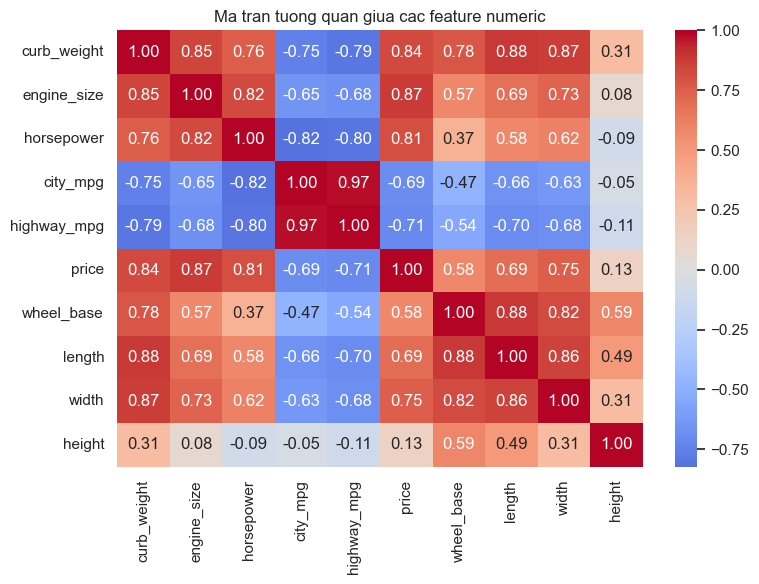

In [24]:
# M2.5: Correlation heatmap
numeric_for_corr = analysis_df[AUTO_FEATURES + ["wheel_base", "length", "width", "height"]]
corr_matrix = numeric_for_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0, ax = ax)
ax.set_title("Ma tran tuong quan giua cac feature numeric")
plt.tight_layout()
plt.show()

NHẬN XÉT
 1. **price** tương quan dương mạnh với **engine_size** (0.87), **curb_weight** (0.84) và **horsepower** (0.81) có hiện tượng đa cộng tuyến.
 2. **price** nhưng tương quan âm với **city_mpg** (-0.69) và **highway_mpg** (-0.71) — xe càng nặng, động cơ càng lớn thì càng đắt và càng tốn nhiên liệu hơn.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

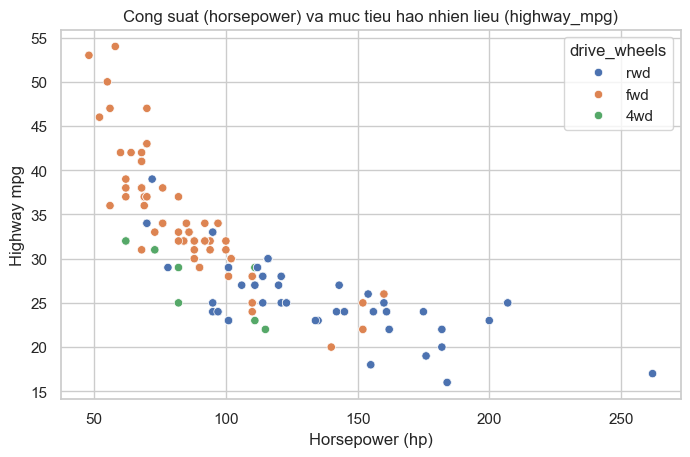

In [25]:
# M2.6: Bieu do tu chon - horsepower và highway_mpg theo biến số drive_wheels
fig, ax = plt.subplots()
sns.scatterplot(data=analysis_df, x = "horsepower", y = "highway_mpg", hue = "drive_wheels", ax = ax)

ax.set_title("Cong suat (horsepower) va muc tieu hao nhien lieu (highway_mpg)")
ax.set_xlabel("Horsepower (hp)")
ax.set_ylabel("Highway mpg")
plt.show()

NHẬN XÉT:
1. **horsepower** và **highway_mpg** có tương quan âm khá mạnh (r ≈ -0.80); 
2. Xe dẫn động cầu sau (`rwd`) có xu hướng công suất cao hơn và mức tiêu hao nhiên liệu kém hơn so với xe dẫn động cầu trước (`fwd`), phù hợp với việc `rwd` cũng là nhóm có giá trung bình cao nhất (≈ 19,760 USD so với ≈ 9,245 USD của `fwd`).

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

## Tổng hợp của sinh viên

**Các phát hiện chính:**

1. Giá xe (`price`) lệch phải rõ rệt: đa số xe nằm trong khoảng 7,000 – 17,000 USD, chỉ một số ít xe hạng sang (BMW, Jaguar, Mercedes-Benz, Porsche) có giá trên 30,000 USD, và đây cũng chính là các outlier theo tiêu chí |z-score| > 2.
2. `engine_size`, `curb_weight` và `horsepower` là ba yếu tố có tương quan dương mạnh nhất với `price` (r lần lượt ≈ 0.87, 0.83, 0.81), trong khi `city_mpg` hay `highway_mpg` tương quan âm khá mạnh (≈ -0.69 và -0.70) — xe càng mạnh, càng nặng thì càng đắt và càng tốn nhiên liệu.
3. Dataset mất cân bằng theo `body_style`: `sedan` (96) và `hatchback` (70) chiếm đa số, trong khi `convertible` (6) và `hardtop` (8) rất ít, khiến các thống kê cho hai nhóm này kém tin cậy hơn.
4. Giá trung bình khác biệt rõ theo `body_style` và `drive_wheels`: `convertible`/`hardtop` và xe dẫn động `rwd` có giá trung bình cao nhất, trong khi `hatchback` và xe dẫn động `fwd` rẻ hơn đáng kể.
5. Missing values phân bố không đều: `normalized_losses` thiếu tới 41/205 dòng (~20%), trong khi hầu hết numeric column khác chỉ thiếu 2-4 dòng, nên `normalized_losses` không được dùng làm feature phân tích chính để tránh loại bỏ quá nhiều quan sát khi drop-na.

**Hạn chế của dataset:**

- Kích thước mẫu nhỏ và một số hãng/nhóm body style chỉ có vài quan sát, nên các kết luận theo nhóm nhỏ (ví dụ `convertible`, `hardtop`) dễ bị nhiễu bởi vài cá thể đặc biệt.
- Dữ liệu thu thập từ năm 1985, phản ánh thị trường xe và công nghệ động cơ của giai đoạn đó, nên các mối quan hệ (ví dụ giữa `horsepower` và `highway_mpg`) có thể không còn đúng với xe hiện đại (động cơ hybrid, xe điện...).

**Ví dụ correlation không đồng nghĩa causation:** `horsepower` tương quan âm với `highway_mpg`, nhưng không có nghĩa là công suất động cơ trực tiếp gây ra mức tiêu hao nhiên liệu cao — nguyên nhân thực sự có thể đến từ các yếu tố đi kèm như `curb_weight` và `engine_size` (xe có động cơ mạnh thường cũng nặng hơn và có dung tích xi-lanh lớn hơn), nên horsepower chỉ là một biến tương quan gián tiếp chứ không phải nguyên nhân duy nhất.

**Câu hỏi nên phân tích tiếp:** Nếu kiểm soát đồng thời `curb_weight` và `engine_size` bằng một mô hình hồi quy đa biến, `horsepower` còn giữ được mức ảnh hưởng đáng kể lên `price` và `highway_mpg` hay không, hay phần lớn hiệu ứng quan sát được chỉ là do confounding giữa các biến này với nhau?